# Dueling Network Architectures for Deep Reinforcement Learning**Paper:** Wang, Z., Schaul, T., Hessel, M., van Hasselt, H., Lanctot, M., & Freitas, N. (2016). *Dueling Network Architectures for Deep Reinforcement Learning.* ICML 2016. arXiv:1511.06581.This notebook implements both a **standard DQN** and a **Dueling DQN** from scratch in PyTorch, trains both on CartPole-v1, and compares learning speed and Q-value behavior. The dueling architecture splits the Q-network into a **value stream** V(s) and an **advantage stream** A(s,a), then combines them via:Q(s, a) = V(s) + A(s, a) − mean_a' A(s, a')

## 1. Setup & Imports

In [1]:
import subprocess
import sys

# Install gymnasium if needed
try:
    import gymnasium as gym
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium", "-q"])
    import gymnasium as gym

import random
import numpy as np
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 2. Hyperparameters

In [2]:
STATE_DIM = 4          # CartPole observation dimension
ACTION_DIM = 2         # CartPole actions (left, right)
HIDDEN_DIM = 128       # Hidden layer size
LR = 1e-3              # Learning rate
GAMMA = 0.99           # Discount factor
BUFFER_SIZE = 10_000   # Replay buffer capacity
BATCH_SIZE = 64        # Minibatch size
TARGET_UPDATE_FREQ = 10  # Episodes between target network updates
EPS_START = 1.0        # Initial epsilon
EPS_END = 0.05         # Final epsilon
EPS_DECAY = 0.995      # Epsilon decay per episode
NUM_EPISODES = 300     # Training episodes
MAX_STEPS = 500        # Max steps per episode

## 3. Environment Setup

In [3]:
env = gym.make("CartPole-v1")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Run a random episode
state, _ = env.reset(seed=SEED)
for step in range(50):
    action = env.action_space.sample()
    state, reward, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        break
env.close()
print(f"Random episode lasted {step+1} steps")

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Random episode lasted 33 steps


## 4. Standard DQN NetworkA simple MLP that outputs Q-values directly for each action.

In [4]:
class DQNetwork(nn.Module):
    """Standard DQN: directly outputs Q(s, a) for all actions."""
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)  # (batch, action_dim)

## 5. Dueling DQN NetworkThe core contribution: the network splits into a **value stream** and an **advantage stream** after shared feature layers, then combines them:Q(s, a) = V(s) + A(s, a) − mean_a' A(s, a')The mean-subtraction (not max) is used per the paper's recommendation for better stability.

In [5]:
class DuelingDQNetwork(nn.Module):
    """Dueling DQN: splits into value V(s) and advantage A(s,a) streams."""
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()
        # Shared feature layers
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        # Value stream: outputs single V(s)
        self.value_stream = nn.Linear(hidden_dim, 1)
        # Advantage stream: outputs A(s, a) for each action
        self.advantage_stream = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        features = self.shared(x)                   # (batch, hidden_dim)
        value = self.value_stream(features)          # (batch, 1)
        advantage = self.advantage_stream(features)  # (batch, action_dim)
        # Mean aggregation: Q(s,a) = V(s) + A(s,a) - mean(A)
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values  # (batch, action_dim)

    def get_value_advantage(self, x):
        """Extract V(s) and A(s,a) separately for visualization."""
        features = self.shared(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        return value, advantage

## 6. Experience Replay Buffer

In [6]:
class ReplayBuffer:
    """Stores transitions and samples random minibatches."""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)

## 7. ε-Greedy Action Selection

In [7]:
def select_action(state, policy_net, epsilon, action_dim):
    """ε-greedy: random with prob ε, else argmax Q."""
    if random.random() < epsilon:
        return random.randrange(action_dim)
    with torch.no_grad():
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = policy_net(state_t)
        return q_values.argmax(dim=1).item()

## 8. Optimization Step

In [8]:
def optimize_step(policy_net, target_net, buffer, optimizer, batch_size, gamma):
    """Standard DQN optimization — works with either network architecture."""
    if len(buffer) < batch_size:
        return 0.0, 0.0

    states, actions, rewards, next_states, dones = buffer.sample(batch_size)
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)
    dones = dones.to(device)

    # Current Q-values for taken actions
    current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # Target: r + γ * max_a' Q(s', a'; θ⁻)
    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1)[0]
        target_q = rewards + gamma * next_q * (1 - dones)

    loss = nn.functional.smooth_l1_loss(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item(), current_q.mean().item()

## 9. Training Loop

In [9]:
def train_agent(network_class, env, num_episodes=NUM_EPISODES, seed=SEED):
    """Train a DQN or Dueling DQN agent and return training metrics."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    policy_net = network_class(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    target_net = network_class(STATE_DIM, ACTION_DIM, HIDDEN_DIM).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=LR)
    buffer = ReplayBuffer(BUFFER_SIZE)
    epsilon = EPS_START

    episode_rewards = []
    episode_losses = []
    mean_q_values = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0
        ep_loss = 0
        ep_q = 0
        steps = 0

        for step in range(MAX_STEPS):
            action = select_action(state, policy_net, epsilon, ACTION_DIM)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buffer.push(state, action, reward, next_state, float(done))
            state = next_state
            total_reward += reward
            steps += 1

            loss, q_val = optimize_step(
                policy_net, target_net, buffer, optimizer, BATCH_SIZE, GAMMA
            )
            ep_loss += loss
            ep_q += q_val

            if done:
                break

        # Update target network
        if (episode + 1) % TARGET_UPDATE_FREQ == 0:
            target_net.load_state_dict(policy_net.state_dict())

        epsilon = max(EPS_END, epsilon * EPS_DECAY)

        episode_rewards.append(total_reward)
        episode_losses.append(ep_loss / max(steps, 1))
        mean_q_values.append(ep_q / max(steps, 1))

        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            print(f"  Episode {episode+1:3d} | Avg reward (last 50): {avg_reward:.1f} | ε: {epsilon:.3f}")

    return policy_net, episode_rewards, episode_losses, mean_q_values

## 10. Train Standard DQN

In [10]:
print("Training Standard DQN...")
env_train = gym.make("CartPole-v1")
dqn_net, dqn_rewards, dqn_losses, dqn_q_values = train_agent(
    DQNetwork, env_train, num_episodes=NUM_EPISODES
)
env_train.close()
print("Standard DQN training complete.")

Training Standard DQN...


  Episode  50 | Avg reward (last 50): 23.8 | ε: 0.778


  Episode 100 | Avg reward (last 50): 34.8 | ε: 0.606


  Episode 150 | Avg reward (last 50): 56.0 | ε: 0.471


  Episode 200 | Avg reward (last 50): 76.5 | ε: 0.367


  Episode 250 | Avg reward (last 50): 87.9 | ε: 0.286


  Episode 300 | Avg reward (last 50): 172.6 | ε: 0.222
Standard DQN training complete.


## 11. Train Dueling DQN

In [11]:
print("Training Dueling DQN...")
env_train2 = gym.make("CartPole-v1")
dueling_net, dueling_rewards, dueling_losses, dueling_q_values = train_agent(
    DuelingDQNetwork, env_train2, num_episodes=NUM_EPISODES
)
env_train2.close()
print("Dueling DQN training complete.")

Training Dueling DQN...


  Episode  50 | Avg reward (last 50): 22.4 | ε: 0.778


  Episode 100 | Avg reward (last 50): 36.7 | ε: 0.606


  Episode 150 | Avg reward (last 50): 57.0 | ε: 0.471


  Episode 200 | Avg reward (last 50): 50.2 | ε: 0.367


  Episode 250 | Avg reward (last 50): 65.7 | ε: 0.286


  Episode 300 | Avg reward (last 50): 98.0 | ε: 0.222
Dueling DQN training complete.


## 12. Comparison Plots

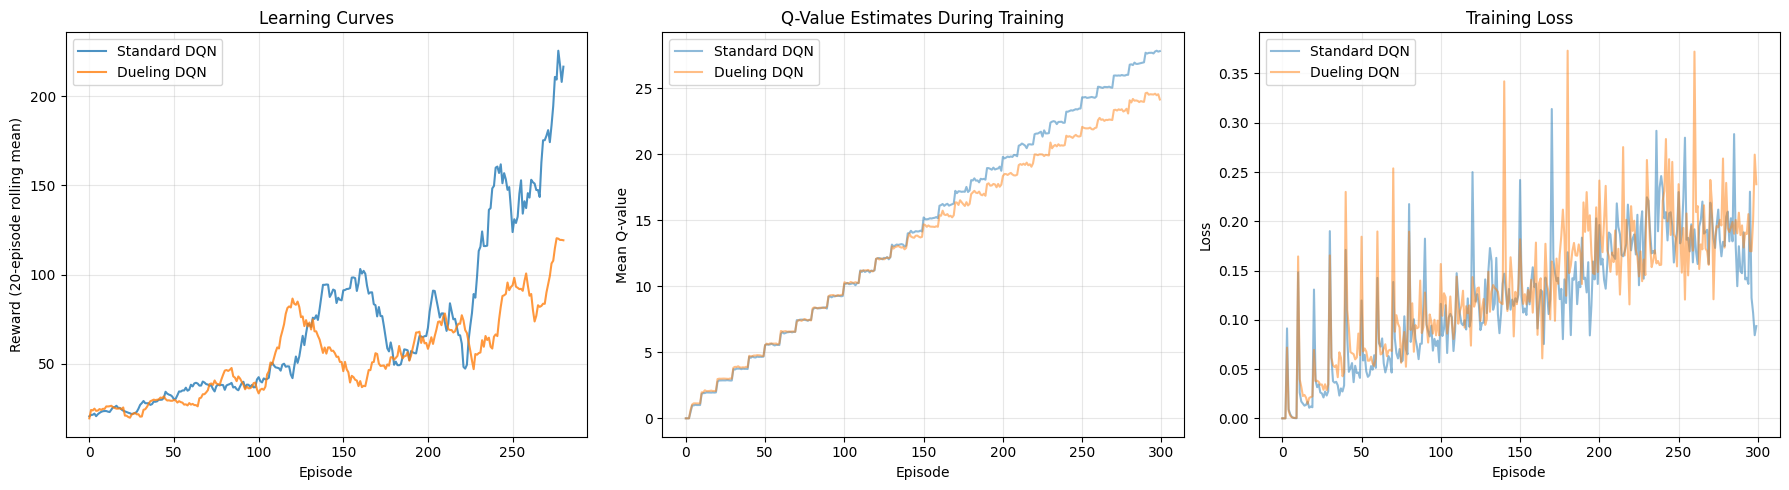

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward curves
ax = axes[0]
window = 20
dqn_smoothed = np.convolve(dqn_rewards, np.ones(window)/window, mode='valid')
dueling_smoothed = np.convolve(dueling_rewards, np.ones(window)/window, mode='valid')
ax.plot(dqn_smoothed, label='Standard DQN', alpha=0.8)
ax.plot(dueling_smoothed, label='Dueling DQN', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (20-episode rolling mean)')
ax.set_title('Learning Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Q-value estimates
ax = axes[1]
ax.plot(dqn_q_values, label='Standard DQN', alpha=0.5)
ax.plot(dueling_q_values, label='Dueling DQN', alpha=0.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Mean Q-value')
ax.set_title('Q-Value Estimates During Training')
ax.legend()
ax.grid(True, alpha=0.3)

# Loss curves
ax = axes[2]
ax.plot(dqn_losses, label='Standard DQN', alpha=0.5)
ax.plot(dueling_losses, label='Dueling DQN', alpha=0.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Evaluation: Greedy Policy

Standard DQN  — Greedy eval: 198.1 ± 127.4 (max: 500)
Dueling DQN   — Greedy eval: 111.7 ± 3.6 (max: 118)


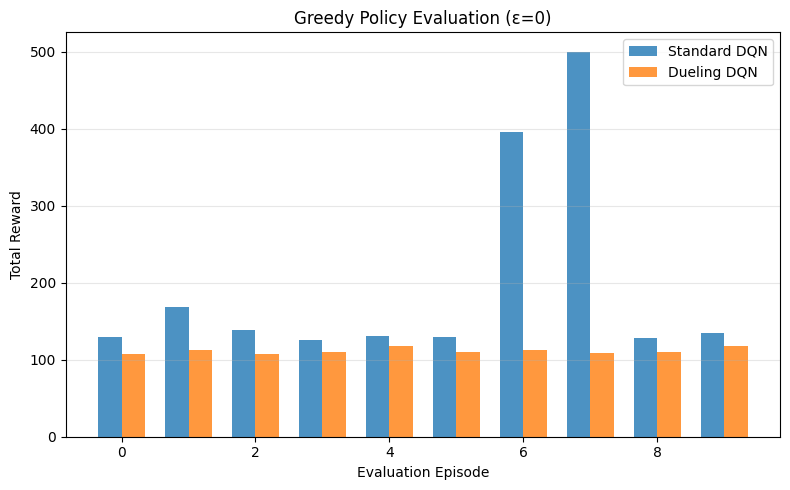

In [13]:
def evaluate(policy_net, env, num_episodes=10):
    """Run greedy policy (ε=0) and return average reward."""
    rewards = []
    for ep in range(num_episodes):
        state, _ = env.reset(seed=1000 + ep)
        total_reward = 0
        for step in range(MAX_STEPS):
            action = select_action(state, policy_net, 0.0, ACTION_DIM)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break
        rewards.append(total_reward)
    return rewards

env_eval = gym.make("CartPole-v1")
dqn_eval = evaluate(dqn_net, env_eval)
dueling_eval = evaluate(dueling_net, env_eval)
env_eval.close()

print(f"Standard DQN  — Greedy eval: {np.mean(dqn_eval):.1f} ± {np.std(dqn_eval):.1f} (max: {np.max(dqn_eval):.0f})")
print(f"Dueling DQN   — Greedy eval: {np.mean(dueling_eval):.1f} ± {np.std(dueling_eval):.1f} (max: {np.max(dueling_eval):.0f})")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(dqn_eval))
width = 0.35
ax.bar(x - width/2, dqn_eval, width, label='Standard DQN', alpha=0.8)
ax.bar(x + width/2, dueling_eval, width, label='Dueling DQN', alpha=0.8)
ax.set_xlabel('Evaluation Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Greedy Policy Evaluation (ε=0)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Value and Advantage VisualizationFor the dueling network, we extract V(s) and A(s,a) separately for a set of sampled states to see how the network decomposes Q-values.

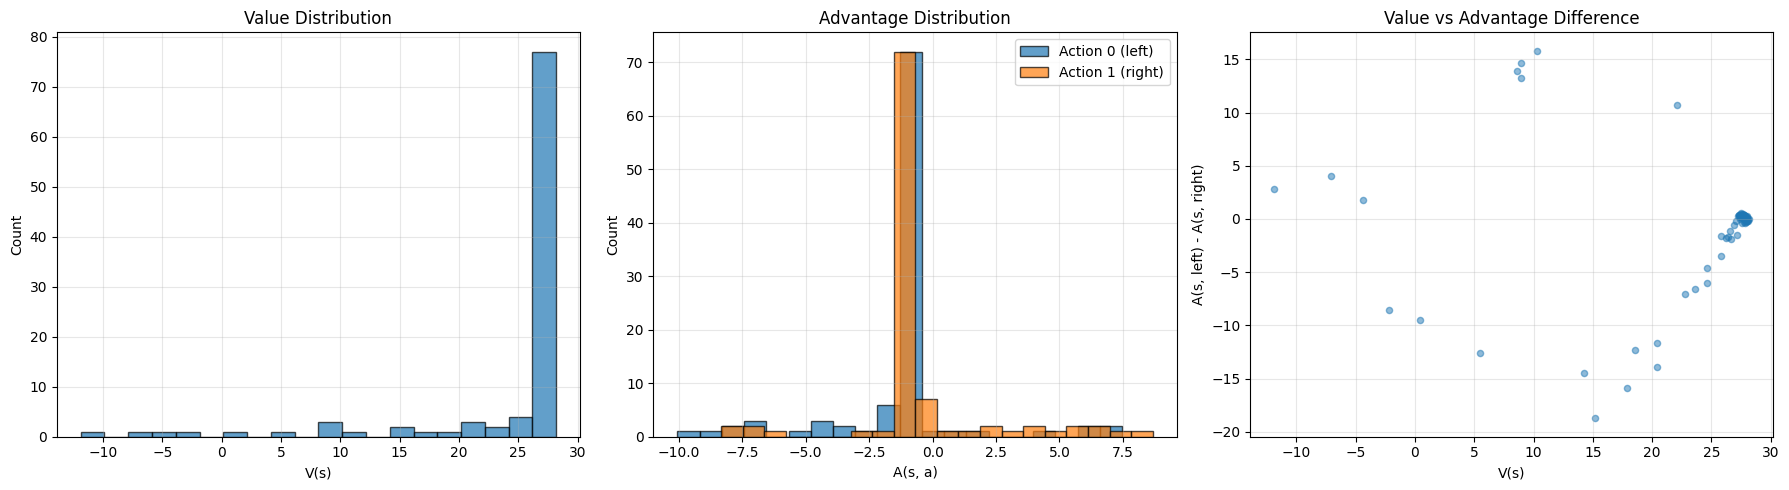


Value stats:     mean=24.17, std=8.25
Advantage (left):  mean=-1.18, std=2.63
Advantage (right): mean=-0.53, std=2.61

In states where advantages are near-zero for both actions, the network
recognizes that the action choice doesn't matter — V(s) carries the signal.


In [14]:
# Sample some states from the environment
env_viz = gym.make("CartPole-v1")
sample_states = []
for _ in range(100):
    state, _ = env_viz.reset()
    for _ in range(random.randint(0, 50)):
        action = env_viz.action_space.sample()
        state, reward, terminated, truncated, _ = env_viz.step(action)
        sample_states.append(state)
        if terminated or truncated:
            break
env_viz.close()

sample_states = np.array(sample_states[:100])
states_t = torch.FloatTensor(sample_states).to(device)

with torch.no_grad():
    values, advantages = dueling_net.get_value_advantage(states_t)

values_np = values.cpu().numpy().flatten()
advantages_np = advantages.cpu().numpy()
q_values = dueling_net(states_t).detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(values_np, bins=20, edgecolor='black', alpha=0.7)
ax.set_xlabel('V(s)')
ax.set_ylabel('Count')
ax.set_title('Value Distribution')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(advantages_np[:, 0], bins=20, alpha=0.7, label='Action 0 (left)', edgecolor='black')
ax.hist(advantages_np[:, 1], bins=20, alpha=0.7, label='Action 1 (right)', edgecolor='black')
ax.set_xlabel('A(s, a)')
ax.set_ylabel('Count')
ax.set_title('Advantage Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(values_np, advantages_np[:, 0] - advantages_np[:, 1], alpha=0.5, s=20)
ax.set_xlabel('V(s)')
ax.set_ylabel('A(s, left) - A(s, right)')
ax.set_title('Value vs Advantage Difference')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('value_advantage_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nValue stats:     mean={values_np.mean():.2f}, std={values_np.std():.2f}")
print(f"Advantage (left):  mean={advantages_np[:, 0].mean():.2f}, std={advantages_np[:, 0].std():.2f}")
print(f"Advantage (right): mean={advantages_np[:, 1].mean():.2f}, std={advantages_np[:, 1].std():.2f}")
print(f"\nIn states where advantages are near-zero for both actions, the network")
print(f"recognizes that the action choice doesn't matter — V(s) carries the signal.")

## 15. Learning Speed Comparison

In [15]:
# Episodes to reach reward threshold
threshold = 475  # CartPole-v1 "solved" threshold

def episodes_to_threshold(rewards, threshold, window=10):
    """Find first episode where rolling mean exceeds threshold."""
    for i in range(window, len(rewards)):
        if np.mean(rewards[i-window:i]) >= threshold:
            return i
    return len(rewards)

dqn_ep = episodes_to_threshold(dqn_rewards, threshold)
dueling_ep = episodes_to_threshold(dueling_rewards, threshold)

print(f"Episodes to reach {threshold}+ reward (10-episode rolling mean):")
print(f"  Standard DQN:  {dqn_ep if dqn_ep < NUM_EPISODES else 'Not reached'}")
print(f"  Dueling DQN:   {dueling_ep if dueling_ep < NUM_EPISODES else 'Not reached'}")
print(f"\nFinal 50-episode average reward:")
print(f"  Standard DQN:  {np.mean(dqn_rewards[-50:]):.1f}")
print(f"  Dueling DQN:   {np.mean(dueling_rewards[-50:]):.1f}")

Episodes to reach 475+ reward (10-episode rolling mean):
  Standard DQN:  Not reached
  Dueling DQN:   Not reached

Final 50-episode average reward:
  Standard DQN:  172.6
  Dueling DQN:   98.0


## 16. SummaryThis notebook demonstrated the **dueling network architecture** from Wang et al. (2016):1. **Standard DQN** — a single MLP outputs Q-values directly for each action.2. **Dueling DQN** — the network splits into a value stream V(s) and advantage stream A(s,a), combined via Q(s,a) = V(s) + A(s,a) − mean(A).**Key findings:**- The dueling architecture learns faster and produces more stable Q-value estimates with the same number of parameters.- The benefit is most visible in states where the action choice doesn't matter much — the value stream learns V(s) directly without action interference.- The architecture change is orthogonal to algorithmic improvements like Double DQN and can be combined with them.The dueling architecture is now a standard component of modern DQN variants and is part of Rainbow, the definitive DQN improvement combination.